<a href="https://colab.research.google.com/github/jabermaslaoui1/amenardi-portal/blob/main/QDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data is ready!
Accuracy: 90.00%


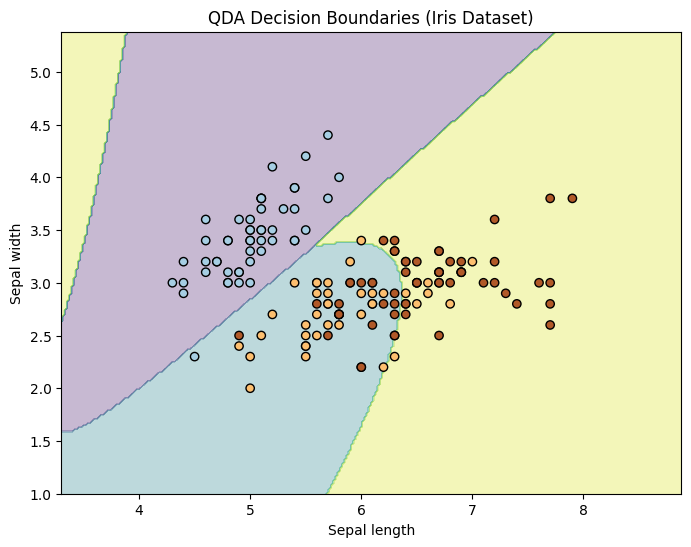

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# ==========================================
# 1. LOAD AND PREPARE DATA
# ==========================================
iris = load_iris()

# Take only the first two features (Sepal length & Sepal width) for 2D plotting
X = iris.data[:, :2]
y = iris.target

# Split into Training and Testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data is ready!")

# ==========================================
# 2. TRAIN THE MODEL & PREDICT
# ==========================================
# Initialize and Train the QDA model
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

# Make predictions on the test set
y_pred = qda.predict(X_test)

# Check and print accuracy
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"Accuracy: {accuracy:.2f}%")

# ==========================================
# 3. VISUALIZATION (DECISION BOUNDARIES)
# ==========================================
# Create a mesh grid to plot the decision boundaries
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Use QDA to predict classes for every point on the background grid
Z = qda.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plotting the results
plt.figure(figsize=(8, 6))

# Draw the colored decision regions
plt.contourf(xx, yy, Z, alpha=0.3)

# Scatter plot of the actual data points
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)

# Labels and styling
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.title('QDA Decision Boundaries (Iris Dataset)')

# Display the plot
plt.show()